In [14]:
"""
    🔹 Step-by-Step Task Breakdown
    Environment Setup: Import required libraries (pandas, numpy, scikit-learn, matplotlib).

    Data Ingestion & Preprocessing: Load the .txt file without headers, assign the correct column names, and separate features (X) from the target variable (y).

    Train-Test Splitting: Divide the dataset into 70% training and 30% testing subsets.

    Exercise 1: Full-Feature Model Training: Initialize Logistic Regression with C=100, fit on training data.
    Exercise 1: Model Evaluation: Predict on test data, calculate accuracy, and count misclassified samples.

    Exercise 2: Feature Subset Extraction: Isolate only PrefixSuffix- (index 5) and AnchorURL (index 13).
    Exercise 2: Subset Model Training & Comparison: Train a new LR model on the 2 features, compute accuracy, and compare with Exercise 1.
    Exercise 2: Decision Boundary Visualization: Create a 2D meshgrid, predict class probabilities across the grid, and plot the decision boundary overlaid with test samples.
"""

'\n    🔹 Step-by-Step Task Breakdown\n    Environment Setup: Import required libraries (pandas, numpy, scikit-learn, matplotlib).\n\n    Data Ingestion & Preprocessing: Load the .txt file without headers, assign the correct column names, and separate features (X) from the target variable (y).\n\n    Train-Test Splitting: Divide the dataset into 70% training and 30% testing subsets.\n\n    Exercise 1: Full-Feature Model Training: Initialize Logistic Regression with C=100, fit on training data.\n    Exercise 1: Model Evaluation: Predict on test data, calculate accuracy, and count misclassified samples.\n\n    Exercise 2: Feature Subset Extraction: Isolate only PrefixSuffix- (index 5) and AnchorURL (index 13).\n    Exercise 2: Subset Model Training & Comparison: Train a new LR model on the 2 features, compute accuracy, and compare with Exercise 1.\n    Exercise 2: Decision Boundary Visualization: Create a 2D meshgrid, predict class probabilities across the grid, and plot the decision boun

In [15]:
    # Import libraries
    # Working with scikit-learn libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
    # Using the header provide in the document "Phishing Dectector using LR.pdf", modified first 2 columns' name, there are 31 columns

    # The dictionary give 31 names, mapped to the dataset 

headers = [
    'Using_IP', 'Long_URL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-',
    'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL',
    'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail',
    'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
    'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
    'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class'
]

    # Load dataset. Adjust sep=',' to sep='\s+' if your file is space/tab delimited.

    # header=None tells pandas that the very first row is actual data, not the names of the columns (like "URL_Length", "Has_SSL", etc.). Because there are no names, pandas will automatically name your columns 0, 1, 2, 3... in this case the last # is 30

    # By explicitly writing sep=',' you are telling Python: Even though this is a text file, the data inside is structured like a CSV, and columns are "seperated" by commas.

df = pd.read_csv('phishing_dataset.txt', header=None, sep=',')


    # takes a list of strings (stored in the variable headers) and overwrites the current column labels of the DataFrame from left to right
df.columns = headers
    # 🔥 FIX: Convert -1 → 0, keep 1 → 1
df['class'] = df['class'].map({-1: 0, 1: 1})

    # Verify it worked
print("Class distribution after remap:")
print(df['class'].value_counts())
    # Should show:
    # 1    XXXX  (phishing)
    # 0    XXXX  (legitimate)
    

print(f"Dataset shape: {df.shape}")
print(df.head())
print(f"Class distribution:\n{df['class'].value_counts()}")

Class distribution after remap:
class
1    6157
0    4898
Name: count, dtype: int64
Dataset shape: (11055, 31)
   Using_IP  Long_URL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0        -1         1         1        1             -1             -1   
1         1         1         1        1              1             -1   
2         1         0         1        1              1             -1   
3         1         0         1        1              1             -1   
4         1         0        -1        1              1             -1   

   SubDomains  HTTPS  DomainRegLen  Favicon  ...  UsingPopupWindow  \
0          -1     -1            -1        1  ...                 1   
1           0      1            -1        1  ...                 1   
2          -1     -1            -1        1  ...                 1   
3          -1     -1             1        1  ...                 1   
4           1      1            -1        1  ...                -1   

   IframeRedirection  A

In [29]:
    # Per document instruction, separate features (first 30 columns) and target (last column) (class)

    # iloc means "integer location" (pulling data by position numbers)

    # [:, :-1] means: take all rows (the :), and take all columns EXCEPT the last one (the :-1)
    # This is the "What You Know" pile of data.....😁
X = df.iloc[:, :-1]

    # This is the "What You Want to Predict" pile
    # [:, -1] means: take all ROWS (the :), and take ONLY THE LAST COLUMN (the -1)
y = df.iloc[:, -1]   # 'class' column: 1 (phishing) or -1 (legitimate)

    # Verify NO -1 remains, quality/spot check
    # why do this?  it is to make sure all values in the last column from code above have 0.  If it has anything other than 0, it is wrong.
print(f"Any -1 values left? {(y == -1).sum()}")  # Should be 0

    # This is called "tuple unpacking" - think of it like this:

    # The train_test_split function doesn't return just ONE thing - it returns FOUR things all packaged together. The equals sign = assigns each returned thing to a variable in order:

    # X_train + y_train = The "homework" (teach the AI using these)

    # X_test + y_test = The "exam" (test if AI actually learned)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Any -1 values left? 0
Train size: 7738, Test size: 3317


In [ ]:
"""
    # HIGH C (100) = "I TRUST the data A LOT." => WIGGLY line (Overfit).
    
    # LOW C (0.01) = "I TRUST the data A LITTLE." => STRAIGHT line (Underfit).

    C=1 = Default / balanced approach

    Think of it like studying for a test:

    Low C = Studying general concepts (might miss details), Studying for MORE a test by learning the concepts and formulas. Even if the questions change, you can figure them out

    High C = Memorizing every practice problem (risks failing if test questions change slightly)

"""

    # random_state=42	Fixed randomness	"Give me the same random results every time I run this"
    # max_iter=1000	Max learning attempts	"Try up to 1000 times to find the best answer"

lr_full = LogisticRegression(C=100, random_state=42, max_iter=1000)
lr_full.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [30]:

"""
    accuracy_score calculates (Correct Predictions) / (Total Predictions).

    (y_test != y_pred_full).sum() leverages boolean masking to count mismatches efficiently without loops.
    
    Accuracy alone can be misleading in imbalanced datasets, but for this phishing dataset (usually ~50/50 split), it's a valid primary metric.

"""

y_pred_full = lr_full.predict(X_test)
accuracy_full = accuracy_score(y_test, y_pred_full)
misclassified_full = (y_test != y_pred_full).sum()

print(f"🔹 Exercise 1 Results (All 30 Features):")
print(f"   Accuracy: {accuracy_full:.4f} ({accuracy_full*100:.2f}%)")
print(f"   Misclassified Samples: {misclassified_full} out of {len(y_test)}")

🔹 Exercise 1 Results (All 30 Features):
   Accuracy: 0.9298 (92.98%)
   Misclassified Samples: 233 out of 3317


In [ ]:
    # Exercise 2: Subset to 2 Features

    # Explanation & Reasoning:
    # Intentionally drop 28 features to observe how much predictive power is lost. This simulates real-world feature selection where simpler models are preferred for interpretability and speed.

    # Extract only index 5 (PrefixSuffix-) and index 13 (AnchorURL)
X_train_2 = X_train.iloc[:, [5, 13]]
X_test_2 = X_test.iloc[:, [5, 13]]

In [ ]:
    #  Explanation & Reasoning:
    # By comparing accuracy_full vs accuracy_2, we quantify the information loss from dropping 28 features.
    # If accuracy drops significantly, it implies those features contain non-linear or complementary signals. If it stays similar, the two features are highly predictive on their own.


lr_two = LogisticRegression(C=100, random_state=42, max_iter=1000)
lr_two.fit(X_train_2, y_train)

y_pred_2 = lr_two.predict(X_test_2)
accuracy_2 = accuracy_score(y_test, y_pred_2)
misclassified_2 = (y_test != y_pred_2).sum()

print(f"\n🔹 Exercise 2 Results (2 Features Only):")
print(f"   Accuracy: {accuracy_2:.4f} ({accuracy_2*100:.2f}%)")
print(f"   Misclassified Samples: {misclassified_2} out of {len(y_test)}")
print(f"   Accuracy Drop: {accuracy_full - accuracy_2:.4f}")


🔹 Exercise 2 Results (2 Features Only):
   Accuracy: 0.8444 (84.44%)
   Misclassified Samples: 516 out of 3317
   Accuracy Drop: 0.0853


In [22]:
print("🔍 UNDERSTANDING YOUR GRAPH")
print("="*50)

print(f"\n1️⃣ Feature 1 (PrefixSuffix-) range:")
print(f"   Min: {X_test_2.iloc[:, 0].min():.2f}")
print(f"   Max: {X_test_2.iloc[:, 0].max():.2f}")

print(f"\n2️⃣ Feature 2 (AnchorURL) range:")
print(f"   Min: {X_test_2.iloc[:, 1].min():.2f}")
print(f"   Max: {X_test_2.iloc[:, 1].max():.2f}")

print(f"\n3️⃣ Class labels (what the colorbar shows):")
print(f"   Unique values: {y_test.unique()}")

print(f"\n4️⃣ Sample data points:")
for i in range(5):
    print(f"   X1={X_test_2.iloc[i, 0]:.2f}, X2={X_test_2.iloc[i, 1]:.2f}, Class={y_test.iloc[i]}")

🔍 UNDERSTANDING YOUR GRAPH

1️⃣ Feature 1 (PrefixSuffix-) range:
   Min: -1.00
   Max: 1.00

2️⃣ Feature 2 (AnchorURL) range:
   Min: -1.00
   Max: 1.00

3️⃣ Class labels (what the colorbar shows):
   Unique values: [0 1]

4️⃣ Sample data points:
   X1=-1.00, X2=1.00, Class=0
   X1=-1.00, X2=1.00, Class=1
   X1=1.00, X2=1.00, Class=1
   X1=-1.00, X2=-1.00, Class=0
   X1=-1.00, X2=-1.00, Class=0


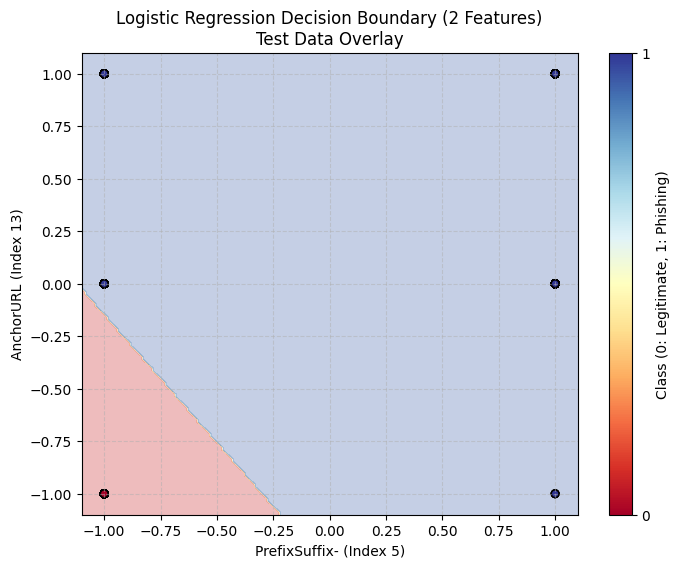


✅ VERIFICATION:
   y_test unique: [0 1]
   Z unique: [0 1]
   Colorbar ticks should be: [0, 1]


In [32]:
    # ============================================
    # PLOTTING - WITH ALL FIXES APPLIED
    # ============================================

    # Create meshgrid
x_min, x_max = X_test_2.iloc[:, 0].min() - 0.1, X_test_2.iloc[:, 0].max() + 0.1
y_min, y_max = X_test_2.iloc[:, 1].min() - 0.1, X_test_2.iloc[:, 1].max() + 0.1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# 🔥 FIX 1: Convert meshgrid to DataFrame with column names (removes warning)
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], 
                       columns=X_train_2.columns)

    # 🔥 FIX 2: Predict using the DataFrame
Z = lr_two.predict(grid_df)
Z = Z.reshape(xx.shape)

    # Create plot
plt.figure(figsize=(8, 6))

    # Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')

    # 🔥 FIX 3: Scatter plot with y_test (which should be 0 and 1)
scatter = plt.scatter(X_test_2.iloc[:, 0], X_test_2.iloc[:, 1], 
                      c=y_test, edgecolor='k', cmap='RdYlBu', s=30)

    # 🔥 FIX 4: Colorbar MUST have ticks [0, 1]
plt.colorbar(scatter, ticks=[0, 1], label='Class (0: Legitimate, 1: Phishing)')

plt.xlabel('PrefixSuffix- (Index 5)')
plt.ylabel('AnchorURL (Index 13)')
plt.title('Logistic Regression Decision Boundary (2 Features)\nTest Data Overlay')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

    # ============================================
    # VERIFICATION - Print what's actually in the plot
    # ============================================
print("\n✅ VERIFICATION:")
print(f"   y_test unique: {y_test.unique()}")
print(f"   Z unique: {np.unique(Z)}")
print(f"   Colorbar ticks should be: [0, 1]")

In [ ]:
print("="*50)
print("🧠 LET'S UNDERSTAND THIS STEP BY STEP")
print("="*50)

    # 1. What are the features?
print("\n1️⃣ FEATURES (X):")
print("   These are the INPUTS to the model.")
print("   Example: PrefixSuffix-, AnchorURL, HTTPS, etc.")
print(f"   Feature 1 (PrefixSuffix-) sample: {X_test_2.iloc[0, 0]}")
print(f"   Feature 2 (AnchorURL) sample: {X_test_2.iloc[0, 1]}")

    # 2. What are the labels?
print("\n2️⃣ LABELS (y):")
print("   These are the OUTPUTS (what we're trying to predict).")
print("   0 = Legitimate, 1 = Phishing")
print(f"   Sample label: {y_test.iloc[0]}")

    # 3. What does the model predict?
print("\n3️⃣ MODEL PREDICTIONS:")
print("   The model takes the features and predicts a class.")
prediction = lr_two.predict([X_test_2.iloc[0].values])
print(f"   For sample 0: Features={X_test_2.iloc[0].values}, Predicted={prediction[0]}, Actual={y_test.iloc[0]}")

    # 4. What does the graph show?
print("\n4️⃣ THE GRAPH:")
print("   - X-axis: Feature 1 (PrefixSuffix-)")
print("   - Y-axis: Feature 2 (AnchorURL)")
print("   - Colorbar: Class label (0 or 1)")
print("   - Red region: Model predicts Phishing (1)")
print("   - Blue region: Model predicts Legitimate (0)")
print("   - Dots: Actual test data, colored by true class")

🧠 LET'S UNDERSTAND THIS STEP BY STEP

1️⃣ FEATURES (X):
   These are the INPUTS to the model.
   Example: PrefixSuffix-, AnchorURL, HTTPS, etc.
   Feature 1 (PrefixSuffix-) sample: -1
   Feature 2 (AnchorURL) sample: 1

2️⃣ LABELS (y):
   These are the OUTPUTS (what we're trying to predict).
   0 = Legitimate, 1 = Phishing
   Sample label: 0

3️⃣ MODEL PREDICTIONS:
   The model takes the features and predicts a class.
   For sample 0: Features=[-1  1], Predicted=1, Actual=0

4️⃣ THE GRAPH:
   - X-axis: Feature 1 (PrefixSuffix-)
   - Y-axis: Feature 2 (AnchorURL)
   - Colorbar: Class label (0 or 1)
   - Red region: Model predicts Phishing (1)
   - Blue region: Model predicts Legitimate (0)
   - Dots: Actual test data, colored by true class


c:\Users\SETUP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import ollama
import numpy as np
from datetime import datetime

    # ============================================
    # 1. CALCULATE TOP 3 FEATURES
    # ============================================
coefs = lr_full.coef_[0]
abs_coefs = np.abs(coefs)
top_indices = np.argsort(abs_coefs)[-3:][::-1]
top_features = [X.columns[i] for i in top_indices]
top_features_str = ", ".join(top_features)

    # ============================================
    # 2. BUILD THE PROMPT (WITHOUT PLACEHOLDERS)
    # ============================================
prompt = f"""
You are a senior security analyst at a cybersecurity firm. Generate a daily phishing detection report based on these results:

**Model Performance:**
- Full Model (30 features): {accuracy_full:.2%}
- Simplified Model (2 features only): {accuracy_2:.2%}
- Accuracy Drop: {accuracy_full - accuracy_2:.2%}
- Misclassified Samples: {misclassified_2} out of {len(y_test)} test samples

**Feature Insights:**
- Top 3 Most Important Features for Detection: {top_features_str}

**Your task:**
Write a concise daily report with exactly these 3 sections:
1. **Executive Summary** (1 sentence)
2. **Key Findings** (3 bullet points)
3. **Action Items & Risks** (3 bullet points, be specific)

Keep the tone professional but direct. No fluff. Mention if the 2-feature model is safe to use or too risky.
"""

# ============================================
# 3. CALL OLLAMA
# ============================================
print("\n🤖 Generating AI-powered report with Ollama...")
print("="*50)


        # ollama.chat(...) = now it is calling an API (even though it's local). Think of it as picking up the phone to call Ollama.
        # model='llama3.2' = Hey Ollama server, wake up Llama3.2 and put him on the line.
        # messages=[...] = You are writing a script for a conversation. Right now, it's just one line.
        # {'role': 'user', 'content': prompt} = on the prompt above at #2 = 'role':'user' = "This is the Human speaking."
        # 'content': prompt = "Here is exactly what the Human said."

"""
        Imagine you ordered a product from Amazon Llama3.2 (the AI).

        response = ollama.chat(...)
        This is the Delivery Driver knocking on your door and handing you a giant Amazon box. The box contains the product, plus bubble wrap, a receipt, and a return label.

        report = response['message']['content']
        This is you opening the box, ignoring the bubble wrap (metadata) and the receipt (role), and pulling out just the product (the text report).

        response = The unopened Amazon box.

        ['message'] = The inner envelope inside the box.

        ['content'] = The product (the item you actually ordered).
        
"""
try:
    response = ollama.chat(
        model='llama3.2',  # installed llama3.2 as of now
        messages=[{'role': 'user', 'content': prompt}]
    )
    
    report = response['message']['content']
    
    # Print the beautiful report
    print("📊 PHISHING DETECTION DAILY REPORT")
    print("="*50)
    print(report)
    print("="*50)

except Exception as e:
    print(f"⚠️ Ollama error: {e}")
    print("Make sure Ollama is running locally (ollama serve) and the model is downloaded.")

    # ============================================
    # 4. SAVE TO FILE (For emailing later)
    # ============================================
timestamp = datetime.now().strftime("%Y-%m-%d")
with open(f"phishing_report_{timestamp}.txt", "w", encoding='utf-8') as f:
    f.write("📊 PHISHING DETECTION DAILY REPORT\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write("="*50 + "\n")
    f.write(report)
    f.write("\n" + "="*50 + "\n")
    f.write(f"\n📈 Raw Metrics:\n")
    f.write(f"  - Full Accuracy: {accuracy_full:.2%}\n")
    f.write(f"  - 2-Feature Accuracy: {accuracy_2:.2%}\n")
    f.write(f"  - Misclassified: {misclassified_2}\n")

print(f"\n✅ Report saved to: phishing_report_{timestamp}.txt")


🤖 Generating AI-powered report with Ollama...
📊 PHISHING DETECTION DAILY REPORT
**Daily Phishing Detection Report**

**Executive Summary:**
Our daily phishing detection report reveals that our full model achieved a high accuracy of 92.98%, while the simplified model with only two features performed at 84.44%. This significant drop in performance highlights the importance of utilizing the full feature set for optimal results.

**Key Findings:**

• The top three most important features for phishing detection are PrefixSuffix-, AnchorURL, and HTTPS, emphasizing the critical role these attributes play in distinguishing legitimate from malicious communications.
• A total of 516 test samples were misclassified by our models, indicating areas where further refinement is necessary to improve overall performance.
• The simplified model's reduced accuracy raises concerns about its viability for production use, as it may lead to a significant decrease in phishing detection rates.

**Action Items